# Recall@k — model vs random baseline

Numbers pulled from `data/clean/baseline/retrieval_summary.json`. With one ground-truth next-track per query, Recall@k equals Hit@k: for each held-out positive `(q, truth)`, score `q` against all 3,827 candidate tracks and check whether `truth` lands in the top k.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

summary_path = Path("../data/clean/baseline/retrieval_summary.json")
summary = json.loads(summary_path.read_text())

ks = [1, 5, 10]
model_recall = [summary[f"hit_at_{k}"] * 100 for k in ks]
random_recall = [summary[f"random_hit_at_{k}"] * 100 for k in ks]

n_queries = summary["n_queries"]
n_candidates = summary["n_candidates"]
lift = [m / r for m, r in zip(model_recall, random_recall)]

for k, m, r, l in zip(ks, model_recall, random_recall, lift):
    print(f"Recall@{k:2d}  model={m:.3f}%  random={r:.3f}%  lift={l:.1f}x")

Recall@ 1  model=0.134%  random=0.026%  lift=5.1x
Recall@ 5  model=1.473%  random=0.131%  lift=11.3x
Recall@10  model=2.811%  random=0.261%  lift=10.8x


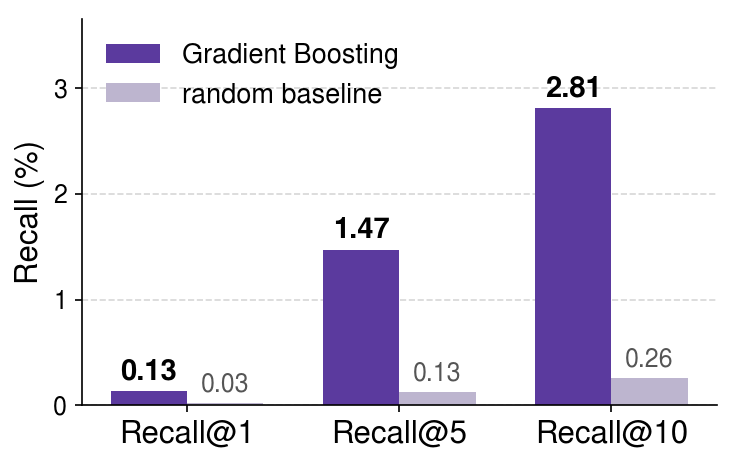

In [2]:
plt.rcParams["font.family"] = ["Helvetica", "Nimbus Sans", "Arial", "sans-serif"]

x = np.arange(len(ks))
width = 0.36

fig, ax = plt.subplots(figsize=(5, 3.2), dpi=150)
bars_model = ax.bar(x - width / 2, model_recall, width,
                    label="Gradient Boosting", color="#5b3a9e", edgecolor="none")
bars_random = ax.bar(x + width / 2, random_recall, width,
                     label="random baseline", color="#bdb5cf", edgecolor="none")

for bar, val in zip(bars_model, model_recall):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom",
            fontsize=14, fontweight="bold")
for bar, val in zip(bars_random, random_recall):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", va="bottom",
            fontsize=12, color="#555555")

ax.set_xticks(x)
ax.set_xticklabels([f"Recall@{k}" for k in ks], fontsize=15)
ax.set_ylabel("Recall (%)", fontsize=15)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=13, frameon=False, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(model_recall) * 1.3)

plt.tight_layout()
plt.savefig("recall_at_k.png", dpi=150)
plt.show()